In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import joblib
import streamlit as st
from imblearn.over_sampling import RandomOverSampler

In [2]:
df= pd.read_csv('SaYoPillow.csv')

In [3]:
df.head()

,sr,rr,t,lm,bo,rem,sr.1,hr,sl
0,93.80,25.680,91.840,16.600,89.840,99.60,1.840,74.20,3
1,91.64,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,96.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,96.92,0.768,68.84,3
4,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0


In [4]:
df.shape

(630, 9)

In [5]:
df.isnull().sum()

sr      0
rr      0
t       0
lm      0
bo      0
rem     0
sr.1    0
hr      0
sl      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sr      630 non-null    float64
 1   rr      630 non-null    float64
 2   t       630 non-null    float64
 3   lm      630 non-null    float64
 4   bo      630 non-null    float64
 5   rem     630 non-null    float64
 6   sr.1    630 non-null    float64
 7   hr      630 non-null    float64
 8   sl      630 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 44.4 KB


In [8]:
df=df.rename(columns={'sr':'snoring rate','rr':'respiration rate','t':'body temperature','lm':'limb movement',
                      "bo":'blood oxygen','rem':'eye movement','sr.1':'sleeping hours',"hr":"heart rate",'sl':'stress level'})

In [9]:
df.head()

,snoring rate,respiration rate,body temperature,limb movement,blood oxygen,eye movement,sleeping hours,heart rate,stress level
0,93.80,25.680,91.840,16.600,89.840,99.60,1.840,74.20,3
1,91.64,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,96.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,96.92,0.768,68.84,3
4,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0


In [10]:
df['stress level'].value_counts()

stress level
3    126
1    126
0    126
2    126
4    126
Name: count, dtype: int64

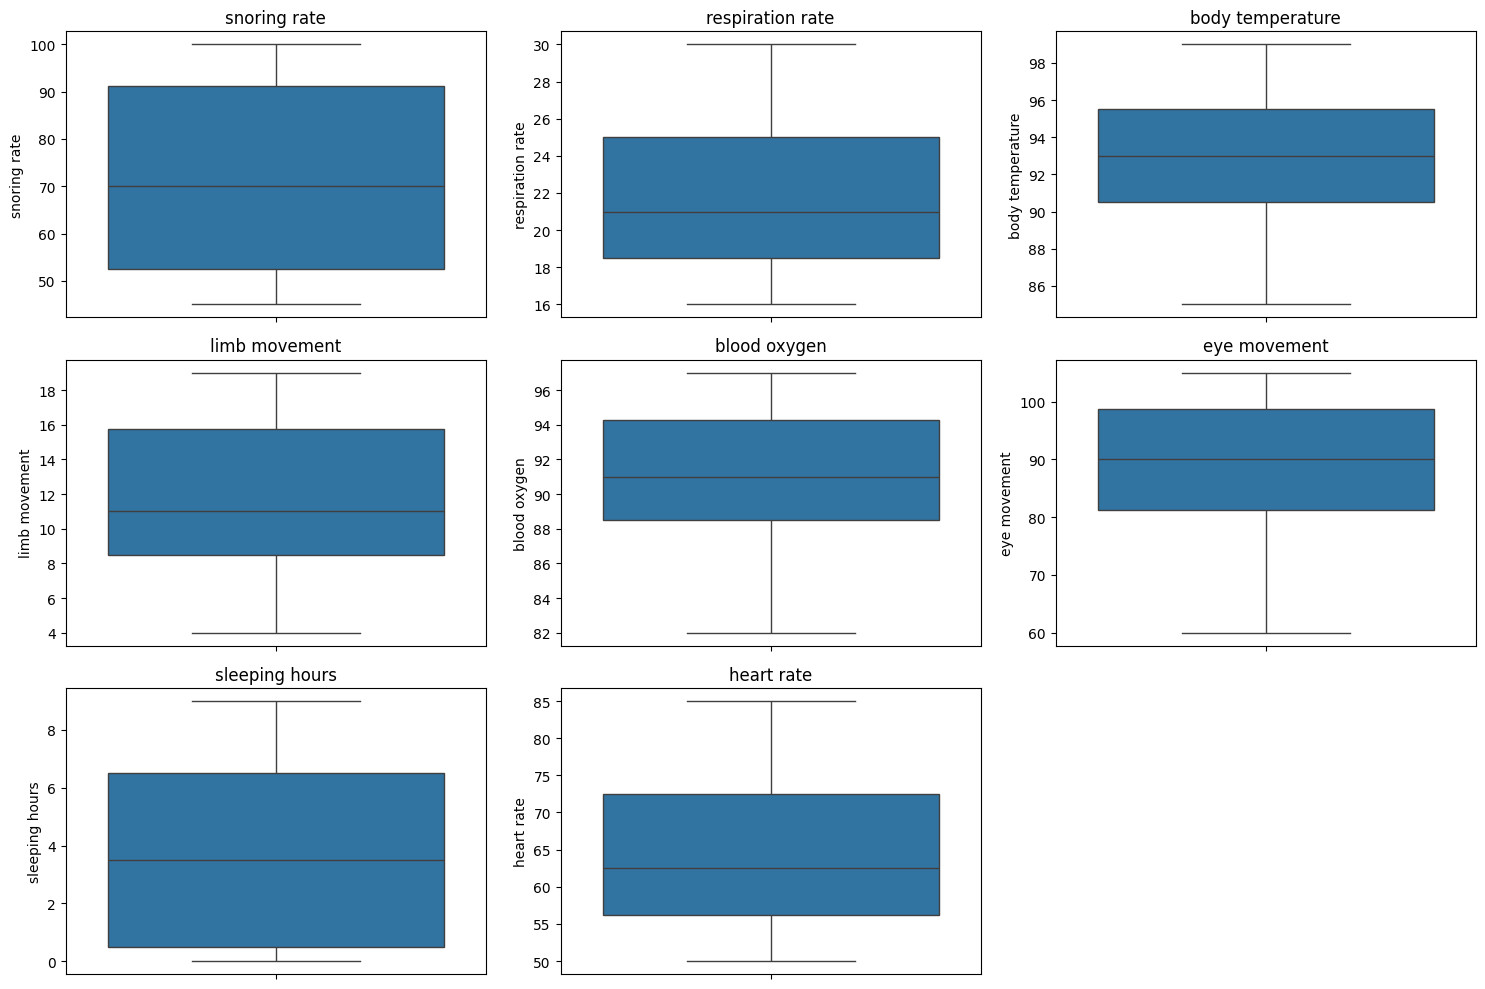

In [11]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

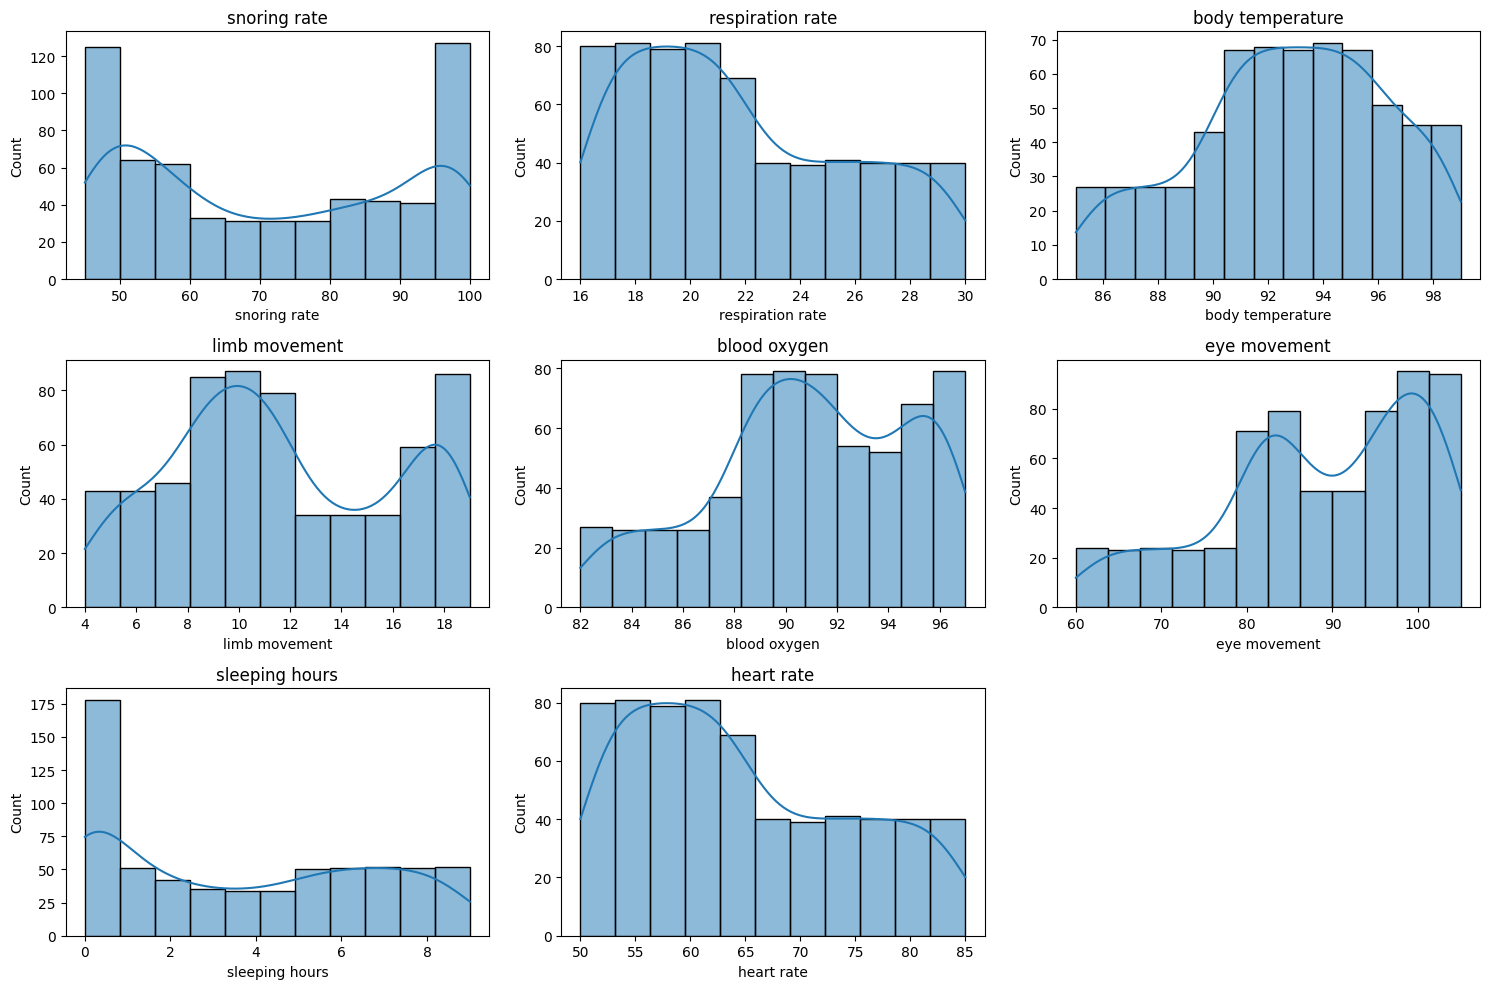

In [12]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

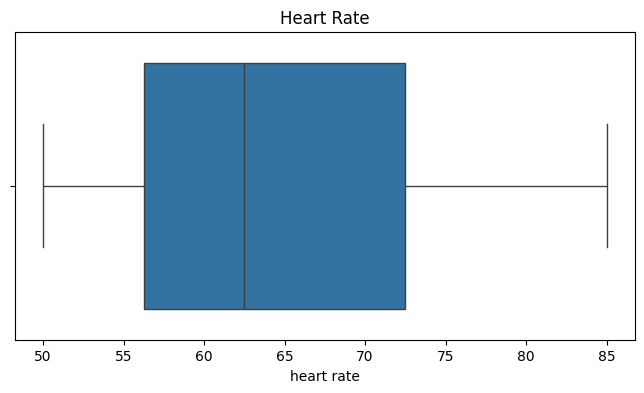

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['heart rate'])
plt.title("Heart Rate")
plt.show()

In [14]:
print(df['body temperature'].describe())

count    630.00000
mean      92.80000
std        3.52969
min       85.00000
25%       90.50000
50%       93.00000
75%       95.50000
max       99.00000
Name: body temperature, dtype: float64


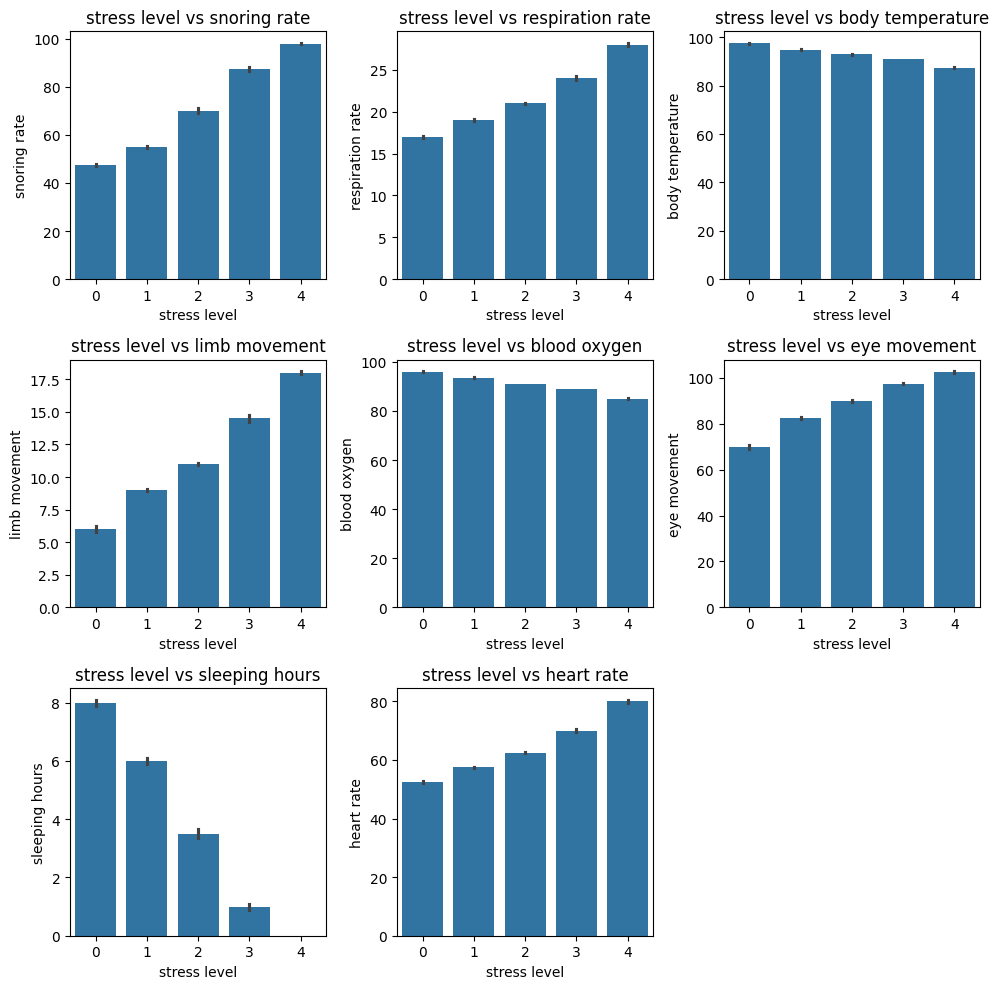

In [15]:
plt.figure(figsize=(10, 10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.barplot(x='stress level', y=col, data=df)
    plt.title(f"stress level vs {col}")
plt.tight_layout()
plt.show()

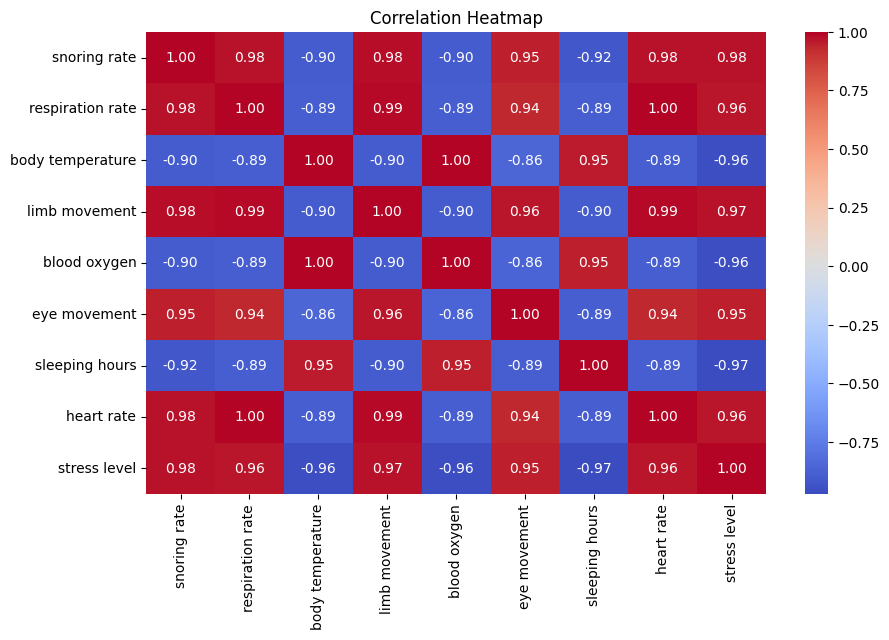

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
df['stress level'].value_counts()

stress level
3    126
1    126
0    126
2    126
4    126
Name: count, dtype: int64

In [18]:
df[df['stress level'] == 2].head()

,snoring rate,respiration rate,body temperature,limb movement,blood oxygen,eye movement,sleeping hours,heart rate,stress level
10,73.44,21.344,93.344,11.344,91.344,91.72,4.016,63.36,2
19,63.68,20.368,92.368,10.368,90.368,86.84,2.552,60.92,2
20,77.60,21.760,93.760,11.760,91.760,93.80,4.640,64.40,2
21,77.28,21.728,93.728,11.728,91.728,93.64,4.592,64.32,2
22,69.76,20.976,92.976,10.976,90.976,89.88,3.464,62.44,2


In [20]:
# Map stress levels to binary classes
df['stress level'] = df['stress level'].apply(lambda x: 0 if x <= 2 else 1)

# Verify the mapping
print(df['stress level'].value_counts())

stress level
0    378
1    252
Name: count, dtype: int64


In [21]:
# Ensure x and y are defined
x = df.drop(['stress level'], axis=1)  # Features
y = df['stress level']  # Target

# Initialize the oversampler
ros = RandomOverSampler(random_state=42)

# Apply oversampling to the features and target
x_balanced, y_balanced = ros.fit_resample(x, y)

# Verify the new class distribution
print(y_balanced.value_counts())

stress level
1    378
0    378
Name: count, dtype: int64


In [22]:
df.head()

,snoring rate,respiration rate,body temperature,limb movement,blood oxygen,eye movement,sleeping hours,heart rate,stress level
0,93.80,25.680,91.840,16.600,89.840,99.60,1.840,74.20,1
1,91.64,25.104,91.552,15.880,89.552,98.88,1.552,72.76,1
2,60.00,20.000,96.000,10.000,95.000,85.00,7.000,60.00,0
3,85.76,23.536,90.768,13.920,88.768,96.92,0.768,68.84,1
4,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0


In [23]:
df.shape

(630, 9)

In [47]:
x = df.drop(['stress level'], axis=1)
y = df['stress level']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [48]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [49]:
# Define the parameter grid for DecisionTreeClassifier
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'random_state': [42]
}

# Initialize the DecisionTreeClassifier
dt = DecisionTreeClassifier()

# Perform GridSearchCV
grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search_dt.fit(x_train_scaled, y_train)

# Get the best parameters and best score
best_params_dt = grid_search_dt.best_params_
best_score_dt = grid_search_dt.best_score_

print(f"Best Parameters for Decision Tree: {best_params_dt}")
print(f"Best Cross-Validation Accuracy for Decision Tree: {best_score_dt:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'random_state': 42, 'splitter': 'random'}
Best Cross-Validation Accuracy for Decision Tree: 1.0000


In [50]:
model_DecisionTree = DecisionTreeClassifier(criterion='gini', splitter='random', random_state=42,
                                             max_depth=None, min_samples_split=2, min_samples_leaf=1)
model_DecisionTree.fit(x_train_scaled, y_train)
y_pred_DecisionTree = model_DecisionTree.predict(x_test_scaled)
accuracy_DecisionTree_test = accuracy_score(y_test, y_pred_DecisionTree)
accuracy_DecisionTree_train = accuracy_score(y_train, model_DecisionTree.predict(x_train_scaled))

In [51]:
print(f"Decision Tree Classifier - Test Accuracy: {accuracy_DecisionTree_test*100:.2f}%")
print(f"Decision Tree Classifier - Train Accuracy: {accuracy_DecisionTree_train*100:.2f}%")

Decision Tree Classifier - Test Accuracy: 100.00%
Decision Tree Classifier - Train Accuracy: 100.00%


In [52]:
# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'random_state': [41]
}

# Initialize the Random Forest Classifier
rf = RandomForestClassifier()

# Perform GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search_rf.fit(x_train_scaled, y_train)

# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Best Parameters for Random Forest: {best_params_rf}")
print(f"Best Cross-Validation Accuracy for Random Forest: {best_score_rf:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


Best Parameters for Random Forest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 41}
Best Cross-Validation Accuracy for Random Forest: 1.0000


In [53]:
model_RandomForest = RandomForestClassifier(random_state=41, max_depth=10, min_samples_leaf=1,
                                  min_samples_split=2, n_estimators=100, max_features='sqrt')
model_RandomForest.fit(x_train_scaled, y_train)
y_pred_RandomForest = model_RandomForest.predict(x_test_scaled)
accuracy_RandomForest_test = accuracy_score(y_test, y_pred_RandomForest)
accuracy_RandomForest_train = accuracy_score(y_train, model_RandomForest.predict(x_train_scaled))

In [54]:
print(f"Random Forest Classifier Accuracy Test: {accuracy_RandomForest_test*100:.2f}%")
print(f"Random Forest Classifier Accuracy Train: {accuracy_RandomForest_train*100:.2f}%")

Random Forest Classifier Accuracy Test: 100.00%
Random Forest Classifier Accuracy Train: 100.00%


In [55]:
# Define the parameter grid for LogisticRegression
param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [100, 200, 500]
}

# Initialize the LogisticRegression model
lr = LogisticRegression()

# Perform GridSearchCV
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search_lr.fit(x_train_scaled, y_train)

# Get the best parameters and best score
best_params_lr = grid_search_lr.best_params_
best_score_lr = grid_search_lr.best_score_

print(f"Best Parameters for Logistic Regression: {best_params_lr}")
print(f"Best Cross-Validation Accuracy for Logistic Regression: {best_score_lr:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters for Logistic Regression: {'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy for Logistic Regression: 1.0000


c:\Users\Electronica Care\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
525 fits failed out of a total of 900.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Electronica Care\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Electronica Care\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [56]:
model_LogisticRegression = LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=100)
model_LogisticRegression.fit(x_train_scaled, y_train)
y_pred_LogisticRegression = model_LogisticRegression.predict(x_test_scaled)
accuracy_LogisticRegression_test = accuracy_score(y_test, y_pred_LogisticRegression)
accuracy_LogisticRegression_train = accuracy_score(y_train, model_LogisticRegression.predict(x_train_scaled))

In [57]:
print(f"Logistic Regression Classifier Accuracy Test: {accuracy_LogisticRegression_test*100:.2f}%")
print(f"Logistic Regression Classifier Accuracy Train: {accuracy_LogisticRegression_train*100:.2f}%")

Logistic Regression Classifier Accuracy Test: 100.00%
Logistic Regression Classifier Accuracy Train: 100.00%


In [58]:
# Define the parameter grid for GaussianNB
param_grid_gnb = {
    'var_smoothing': np.logspace(0, -9, num=100)  # Example range for var_smoothing
}

# Initialize the GaussianNB model
gnb = GaussianNB()

# Perform GridSearchCV
grid_search_gnb = GridSearchCV(estimator=gnb, param_grid=param_grid_gnb, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search_gnb.fit(x_train_scaled, y_train)

# Get the best parameters and best score
best_params_gnb = grid_search_gnb.best_params_
best_score_gnb = grid_search_gnb.best_score_

print(f"Best Parameters for GaussianNB: {best_params_gnb}")
print(f"Best Cross-Validation Accuracy for GaussianNB: {best_score_gnb:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters for GaussianNB: {'var_smoothing': np.float64(1.0)}
Best Cross-Validation Accuracy for GaussianNB: 1.0000


In [59]:
model_GaussianNB = GaussianNB(var_smoothing=np.float64(1.0))
model_GaussianNB.fit(x_train_scaled, y_train)
y_pred_GaussianNB = model_GaussianNB.predict(x_test_scaled)
accuracy_GaussianNB_test = accuracy_score(y_test, y_pred_GaussianNB)
accuracy_GaussianNB_train = accuracy_score(y_train, model_GaussianNB.predict(x_train_scaled))

In [60]:
print(f'GaussianNB Classifier Accuracy Train: {accuracy_DecisionTree_train*100:.2f}')
print(f'GaussianNB Classifier Accuracy Test: {accuracy_GaussianNB_test*100:.2f}')

GaussianNB Classifier Accuracy Train: 100.00
GaussianNB Classifier Accuracy Test: 100.00


In [61]:
# Define the parameter grid
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid']
}

# Initialize the SVC model
svc = SVC(probability=True, random_state=42)

# Perform GridSearchCV
grid_search_svc = GridSearchCV(estimator=svc, param_grid=param_grid_svc, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search_svc.fit(x_train_scaled, y_train)

# Get the best parameters and best score
best_params_svc = grid_search_svc.best_params_
best_score_svc = grid_search_svc.best_score_

print(f"Best Parameters for SVC: {best_params_svc}")
print(f"Best Cross-Validation Accuracy for SVC: {best_score_svc:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters for SVC: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Accuracy for SVC: 1.0000


In [62]:
model_svc = SVC(kernel='rbf', C=0.1, gamma='scale')
model_svc.fit(x_train_scaled, y_train)
y_pred_svc = model_svc.predict(x_test_scaled)
accuracy_svc_test = accuracy_score(y_test, y_pred_svc)
accuracy_svc_train = accuracy_score(y_train, model_svc.predict(x_train_scaled))

In [63]:
print(f"SVC Classifier Accuracy Test: {accuracy_svc_test*100:.2f}%")
print(f"SVC Classifier Accuracy Train: {accuracy_svc_train*100:.2f}%")

SVC Classifier Accuracy Test: 100.00%
SVC Classifier Accuracy Train: 100.00%


In [64]:
# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Initialize the XGBoost Classifier
xgb = XGBClassifier(random_state=42)

# Perform GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search_xgb.fit(x_train_scaled, y_train)

# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"Best Parameters for XGBoost: {best_params_xgb}")
print(f"Best Cross-Validation Accuracy for XGBoost: {best_score_xgb:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters for XGBoost: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-Validation Accuracy for XGBoost: 0.9977


In [65]:
model_XGB = XGBClassifier(random_state=42,colsample_bytree= 0.8, gamma= 0, learning_rate= 0.01,max_depth= 3,
                           n_estimators= 100, subsample= 0.8)
model_XGB.fit(x_train_scaled, y_train)
y_pred_XGB = model_XGB.predict(x_test_scaled)
accuracy_XGB_test = accuracy_score(y_test, y_pred_XGB)
accuracy_XGB_train = accuracy_score(y_train, model_XGB.predict(x_train_scaled))

In [66]:
print(f"XGBoost Classifier Accuracy Test: {accuracy_XGB_test*100:.2f}%")
print(f"XGBoost Classifier Accuracy Train: {accuracy_XGB_train*100:.2f}%")

XGBoost Classifier Accuracy Test: 99.47%
XGBoost Classifier Accuracy Train: 100.00%


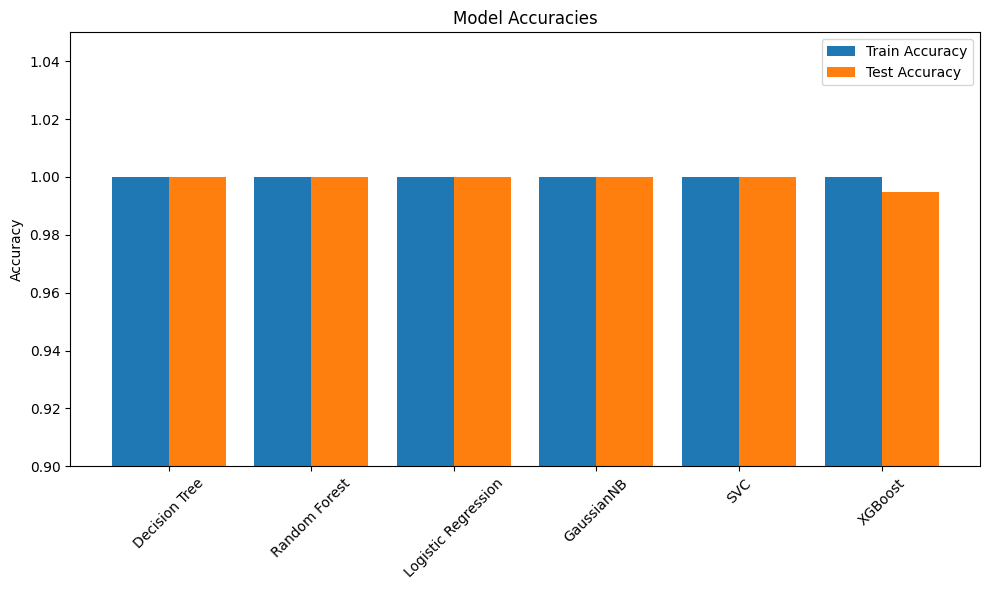

In [67]:
# Define model names and their corresponding accuracies
models = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'GaussianNB', 'SVC', 'XGBoost']
train_accuracies = [
    accuracy_DecisionTree_train,
    accuracy_RandomForest_train,
    accuracy_LogisticRegression_train,
    accuracy_GaussianNB_train,
    accuracy_svc_train,
    accuracy_XGB_train
]
test_accuracies = [
    accuracy_DecisionTree_test,
    accuracy_RandomForest_test,
    accuracy_LogisticRegression_test,
    accuracy_GaussianNB_test,
    accuracy_svc_test,
    accuracy_XGB_test
]

# Create a bar plot
x = range(len(models))
plt.figure(figsize=(10, 6))
plt.bar(x, train_accuracies, width=0.4, label='Train Accuracy', align='center')
plt.bar([i + 0.4 for i in x], test_accuracies, width=0.4, label='Test Accuracy', align='center')
plt.xticks([i + 0.2 for i in x], models, rotation=45)
plt.ylim(0.9, 1.05)
plt.ylabel('Accuracy')
plt.title('Model Accuracies')
plt.legend()
plt.tight_layout()
plt.show()

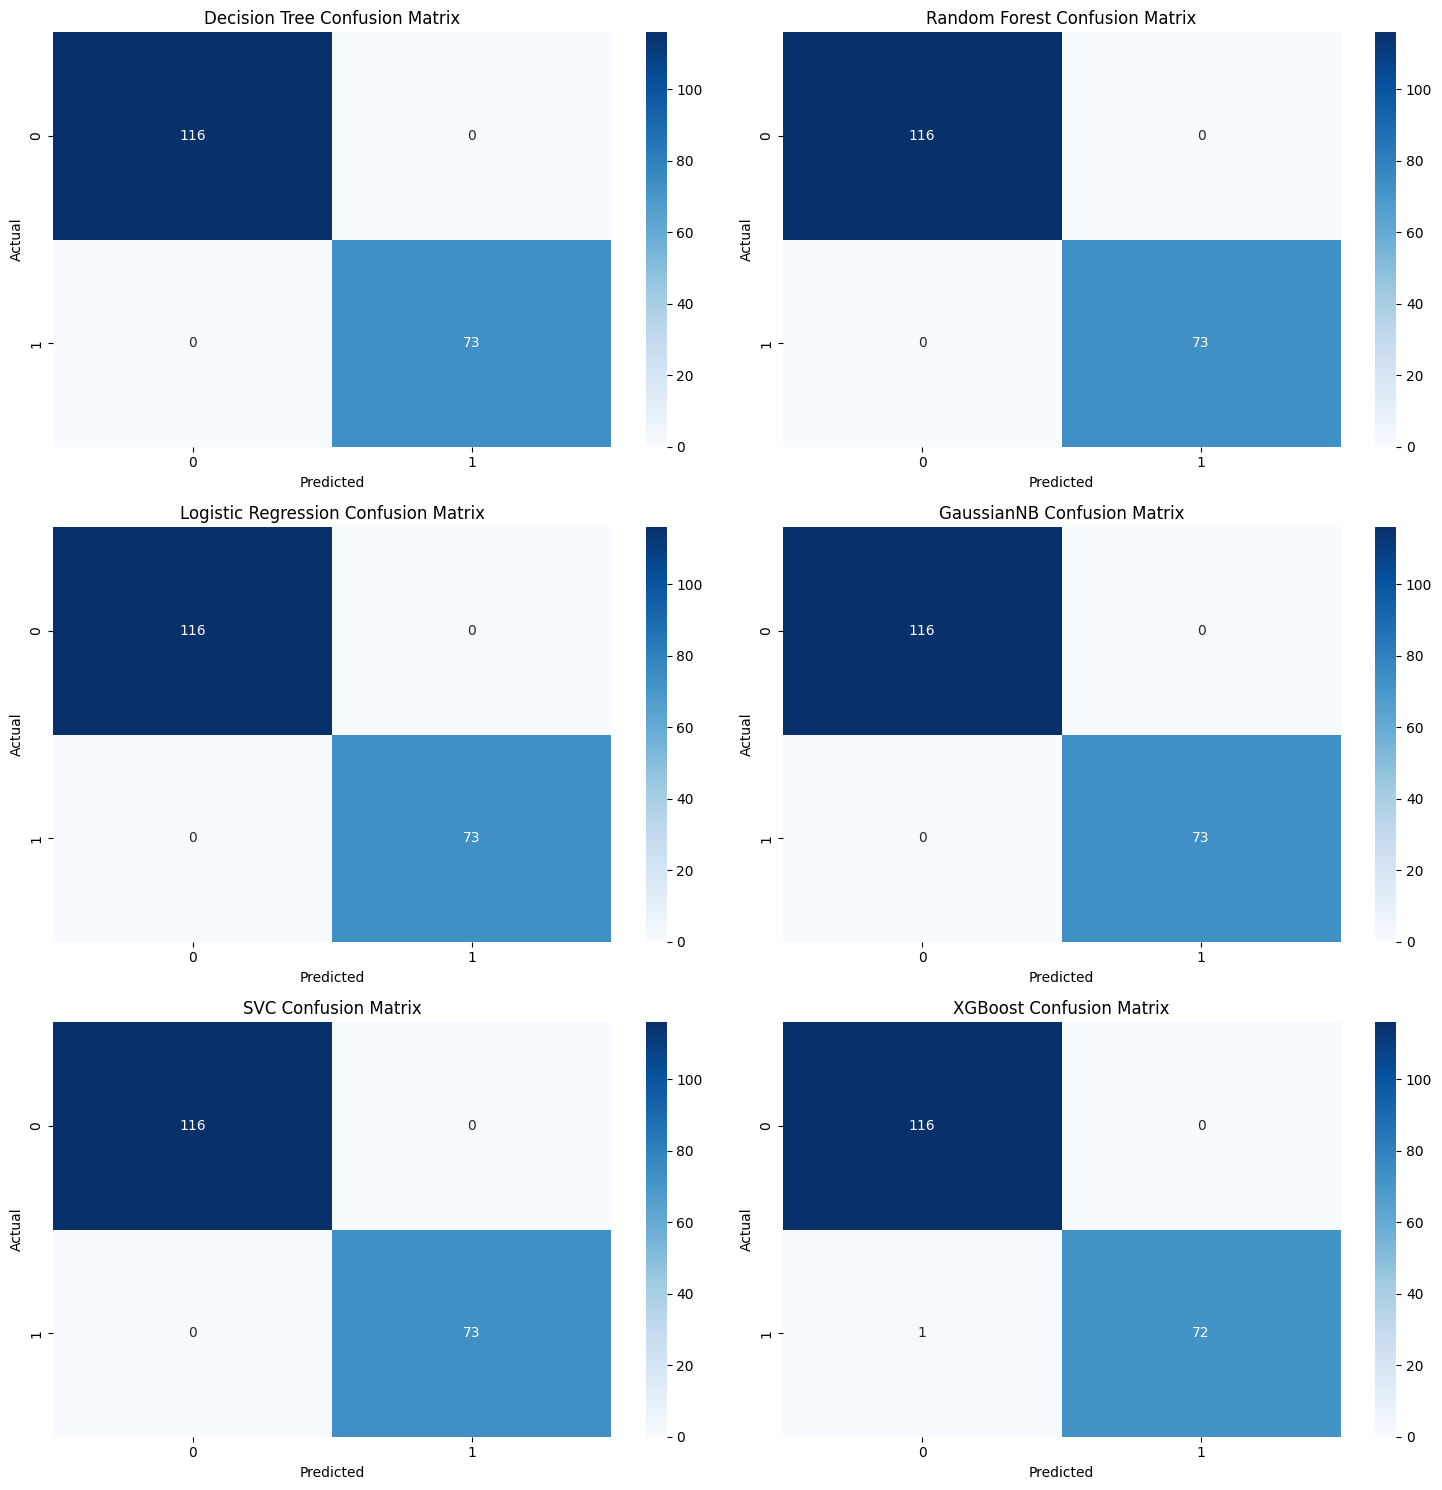

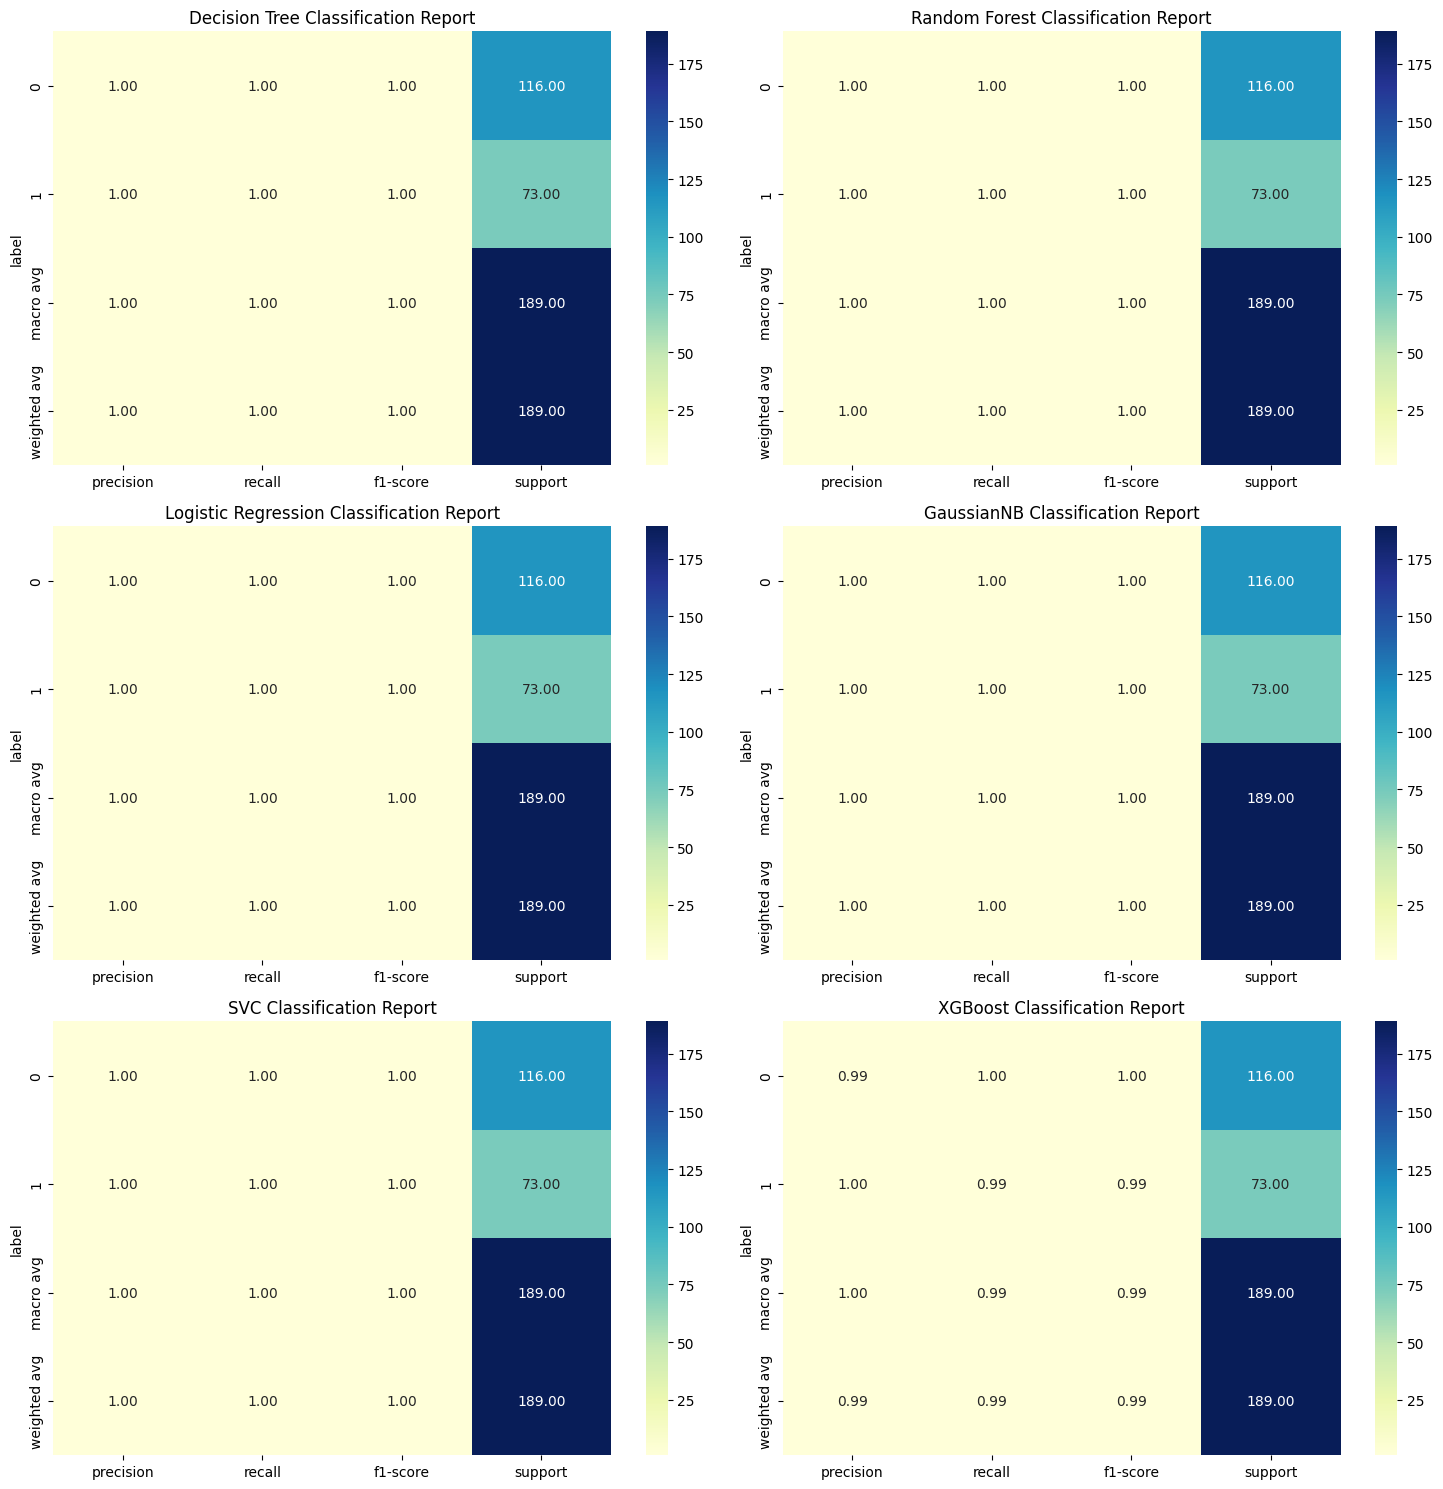

In [68]:
# Function to plot confusion matrix
def plot_confusion_matrix(ax, cm, title):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

# Function to plot classification report
def plot_classification_report(ax, report, title):
    report_data = []
    for label, metrics in report.items():
        if isinstance(metrics, dict):  # Skip 'accuracy' key
            metrics['label'] = label
            report_data.append(metrics)
    report_df = pd.DataFrame(report_data).set_index('label')
    sns.heatmap(report_df, annot=True, cmap='YlGnBu', fmt='.2f', ax=ax)
    ax.set_title(title)


# Calculate confusion matrices
cm_dt = confusion_matrix(y_test, y_pred_DecisionTree)
cm_rf = confusion_matrix(y_test, y_pred_RandomForest)
cm_lr = confusion_matrix(y_test, y_pred_LogisticRegression)
cm_gnb = confusion_matrix(y_test, y_pred_GaussianNB)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cm_xgb = confusion_matrix(y_test, y_pred_XGB)

# Create subplots for confusion matrices
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plot_confusion_matrix(axes[0, 0], cm_dt, "Decision Tree Confusion Matrix")
plot_confusion_matrix(axes[0, 1], cm_rf, "Random Forest Confusion Matrix")
plot_confusion_matrix(axes[1, 0], cm_lr, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(axes[1, 1], cm_gnb, "GaussianNB Confusion Matrix")
plot_confusion_matrix(axes[2, 0], cm_svc, "SVC Confusion Matrix")
plot_confusion_matrix(axes[2, 1], cm_xgb, "XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()


# Generate classification reports
report_dt = classification_report(y_test, y_pred_DecisionTree, output_dict=True)
report_rf = classification_report(y_test, y_pred_RandomForest, output_dict=True)
report_lr = classification_report(y_test, y_pred_LogisticRegression, output_dict=True)
report_gnb = classification_report(y_test, y_pred_GaussianNB, output_dict=True)
report_svc = classification_report(y_test, y_pred_svc, output_dict=True)
report_xgb = classification_report(y_test, y_pred_XGB, output_dict=True)

# Create subplots for classification reports
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plot_classification_report(axes[0, 0], report_dt, "Decision Tree Classification Report")
plot_classification_report(axes[0, 1], report_rf, "Random Forest Classification Report")
plot_classification_report(axes[1, 0], report_lr, "Logistic Regression Classification Report")
plot_classification_report(axes[1, 1], report_gnb, "GaussianNB Classification Report")
plot_classification_report(axes[2, 0], report_svc, "SVC Classification Report")
plot_classification_report(axes[2, 1], report_xgb, "XGBoost Classification Report")
plt.tight_layout()
plt.show()


In [69]:
# Save the trained SVC model
joblib.dump(model_XGB, 'XGB.pkl')

# Load the saved model
loaded_model = joblib.load('XGB.pkl')

# Predict using the loaded model
y_pred_loaded = loaded_model.predict(x_test_scaled)

# Evaluate the loaded model
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)
print(f"Accuracy of the loaded SVC model: {accuracy_loaded * 100:.2f}%")

Accuracy of the loaded SVC model: 99.47%
